In [ ]:
import psycopg2
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

conn = psycopg2.connect(
    user="your_username", 
    host="localhost", 
    password="your_password", 
    database="your_database", 
    port = 5432)

df = pd.read_sql("SELECT * FROM superstore", conn)
df = df.dropna()
for col in ('order_date', 'ship_date'):
    df[col] = pd.to_datetime(df[col], dayfirst=True)
    
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month

C:\Users\bmuza\AppData\Local\Temp\ipykernel_14168\1571761566.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM superstore", conn)


In [ ]:
# REVENUE TREND - GROUP BY

revenue_trend = df.groupby(["year"], as_index=False)["sales"].sum()

print(revenue_trend)

   year      sales
0  2015  479856.27
1  2016  454315.84
2  2017  597225.74
3  2018  721209.75


In [ ]:
# CATEGORY COMPARISON - GROUP BY

category_comparison = df.groupby(["category"], as_index= False)["sales"].sum()

print(category_comparison)

          category      sales
0        Furniture  723538.65
1  Office Supplies  703212.77
2       Technology  825856.18


In [6]:
# TOP CUSTOMERS - GROUP BY

top_customers = df.groupby(["customer_name"], as_index=False)["sales"].sum().sort_values(by= "sales", ascending = False).head(10)

print(top_customers)

          customer_name     sales
686         Sean Miller  25043.07
730        Tamara Chand  19052.22
622        Raymond Buch  15117.35
757        Tom Ashbrook  14595.62
6         Adrian Barton  14473.57
441        Ken Lonsdale  14175.23
671        Sanjit Chand  14142.34
334        Hunter Lopez  12873.30
672        Sanjit Engle  12209.44
156  Christopher Conant  12129.08


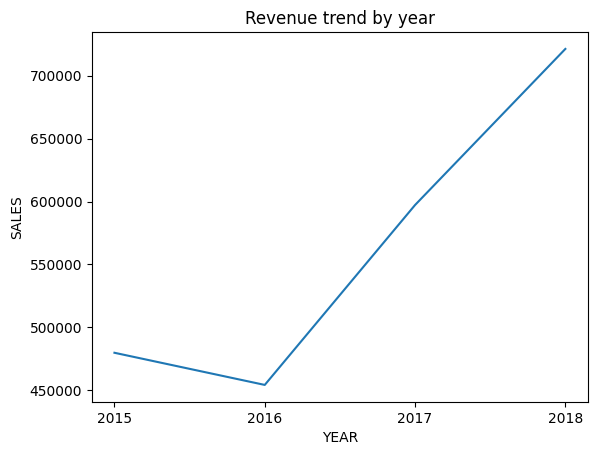

In [10]:
# REVENUE TREND - CHART

x = revenue_trend["year"]
y = revenue_trend["sales"]

plt.plot(x, y)
plt.xticks(x)
plt.title("Revenue trend by year")
plt.xlabel("YEAR")
plt.ylabel("SALES")
plt.show()

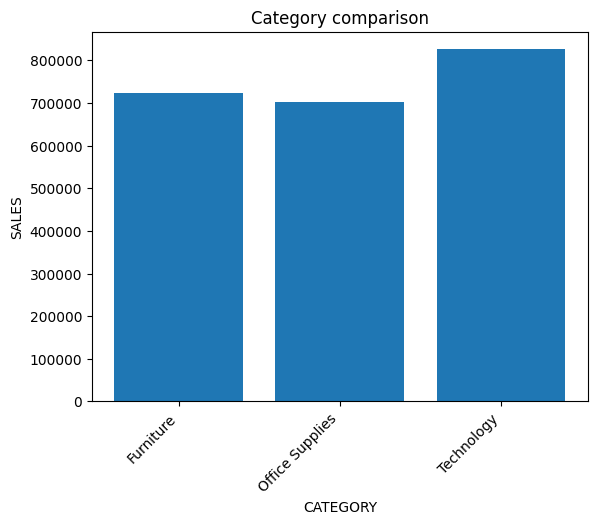

In [11]:
# CATEGORY COMPARISON - CHART

x = category_comparison["category"]
y = category_comparison["sales"]

plt.bar(x, y)
plt.xticks(rotation= 45, ha = 'right')
plt.title("Category comparison")
plt.xlabel("CATEGORY")
plt.ylabel("SALES")
plt.show()

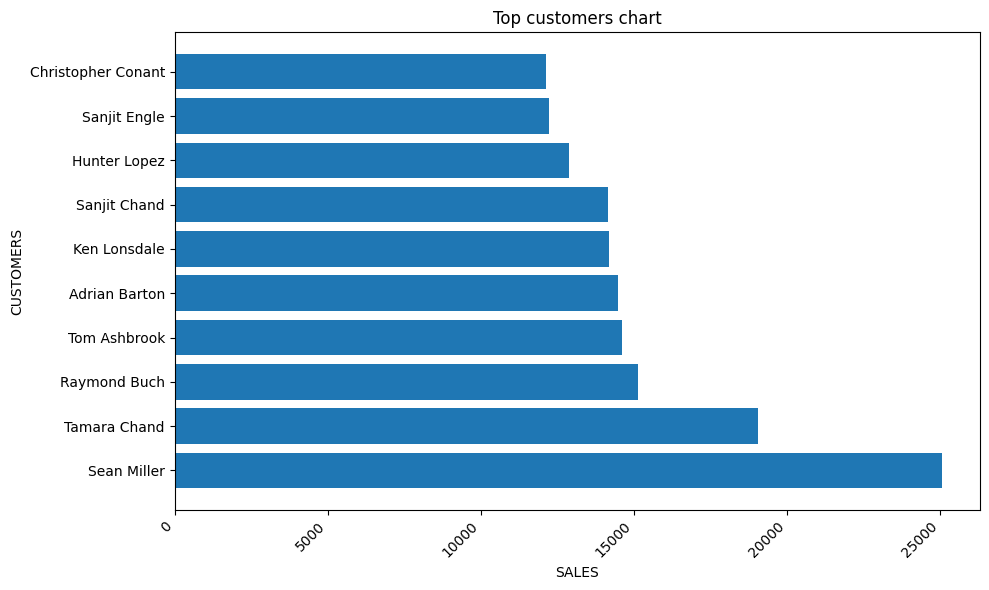

In [14]:
# TOP CUSTOMERS - CHART
x = top_customers["customer_name"]
y = top_customers["sales"]

plt.figure(figsize=(10, 6))
plt.barh(top_customers["customer_name"], top_customers["sales"])
plt.xticks(rotation = 45, ha = "right")
plt.title("Top customers chart")
plt.xlabel("SALES")
plt.ylabel("CUSTOMERS")
plt.tight_layout()
plt.show()